In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import load_and_format_sharks_gals

In [173]:
REGION = 'wide-N'
AREA_ALL, AREA_MASKED = 0.02748648583, 0.02565146777
area_ratio = AREA_ALL / AREA_MASKED

IDS = 'Nessie'  # 'id_fof' or 'Nessie'

N_BOOTSTRAP = 1000
RNG = np.random.default_rng(seed=42)

gals, groups = load_and_format_sharks_gals(
    "/Users/sp624AA/Downloads/group_finding_mocks/galaxies_shark.parquet",
    region=REGION
)


/opt/homebrew/anaconda3/envs/nessie_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/sp624AA/Code/groupfinder_masking/src/utils.py:344: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  groups["is_red_bcg"] = groups[group_col].map(bcg_is_red).fillna(False).astype(bool)


In [174]:
# save down a copy of wide -s 
#gals.to_parquet("/Users/sp624AA/Code/waves_randoms/test_south.parquet")

In [177]:
my_mask_gals = pd.read_parquet('/Users/sp624AA/Code/waves_randoms/waves-wide_n_my_mask_mock.parquet')

In [179]:
my_mask_gals.head()

,ra,dec,in_region,starmask,ghostmask,polygon_mask,realisation
0,215.745575,-2.957536,True,False,False,False,0
1,188.054062,1.607985,True,False,False,False,0
2,189.807495,-0.410635,True,False,False,False,0
3,186.320068,-0.566067,True,False,False,False,0
4,178.945206,-1.543200,True,False,False,False,0


In [5]:
gals.head()

,ra,dec,id_group_sky,redshift_cosmological,redshift_observed,mass_stellar_bulge,mass_stellar_disk,mass_virial_hosthalo,mass_virial_subhalo,id_fof,...,log_stellar_mass_bcg,fof_halo_mass,log_fof_halo_mass,is_red,L,group_L,log_group_L,n_group_fof,group_stellar_mass,log_group_stellar_mass
0,215.745575,-2.957536,-1,0.119346,0.117626,9.426065e+07,3.834027e+08,1.171090e+11,1.171090e+11,-1,...,8.853047,1.171090e+11,11.068590,False,1.012862e+09,1.012862e+09,9.005550,1,7.129303e+08,8.853047
1,188.054062,1.607985,95337200000052,0.109412,0.110086,1.613971e+10,5.222305e+09,1.042690e+12,1.027637e+12,-1,...,10.503568,1.042690e+12,12.018155,False,3.717104e+10,3.717104e+10,10.570205,1,3.188361e+10,10.503568
2,189.807495,-0.410635,87038500000045,0.175471,0.173711,1.891849e+09,2.304678e+09,3.001886e+11,2.826997e+11,-1,...,9.796815,3.001886e+11,11.477394,False,9.118888e+09,9.118888e+09,9.959942,1,6.263474e+09,9.796815
3,186.320068,-0.566067,-1,0.111309,0.110718,2.470276e+08,2.687760e+09,1.852934e+11,1.835224e+11,-1,...,9.641501,1.852934e+11,11.267860,False,5.878469e+09,5.878469e+09,9.769264,1,4.380279e+09,9.641501
4,28.609648,-28.424871,107758100000002,0.025891,0.024037,0.000000e+00,1.018892e+08,7.231314e+12,4.095493e+10,1198360,...,11.519673,7.940233e+13,13.899833,False,1.582132e+08,8.161898e+11,11.911791,72,1.228313e+12,12.089309


In [180]:
# join gals and my mask gals on ra dec, k
combined_gals = gals.merge(my_mask_gals, on=['ra', 'dec'], how='inner')

In [181]:
combined_gals['my_mask'] = (combined_gals['starmask'] == 0) & (combined_gals['polygon_mask'] == 0) & (combined_gals['ghostmask'] == 0)

In [182]:
combined_gals['my_mask'] = ~combined_gals['my_mask']

In [ ]:
# save the combined gals with the new masked column replaced
#combined_gals['masked'] = combined_gals['my_mask']
#combined_gals.to_parquet("/Users/sp624AA/Downloads/group_finding_mocks/galaxies_s.parquet")

In [14]:
combined_gals = combined_gals[['ra', 'dec', 'starmask', 'ghostmask', 'polygon_mask', 'my_mask', 'masked']]

In [15]:
combined_gals.head()

,ra,dec,starmask,ghostmask,polygon_mask,my_mask,masked
0,215.745575,-2.957536,False,False,False,False,False
1,188.054062,1.607985,False,False,False,False,False
2,189.807495,-0.410635,False,False,False,False,False
3,186.320068,-0.566067,False,False,False,False,False
4,178.945206,-1.543200,False,False,False,False,False


In [17]:
conflicts = combined_gals['my_mask'] != combined_gals['masked']

In [21]:
len(conflicts), conflicts.sum()

(425498, np.int64(13083))

In [25]:
data_conf = combined_gals[conflicts]

In [96]:
data_conf['starmask'].sum(), data_conf['masked'].sum()

(np.int64(13083), np.int64(0))

In [95]:
data_conf['']

34        False
78        False
91        False
119       False
183       False
          ...  
425403    False
425406    False
425414    False
425436    False
425481    False
Name: masked, Length: 13083, dtype: bool

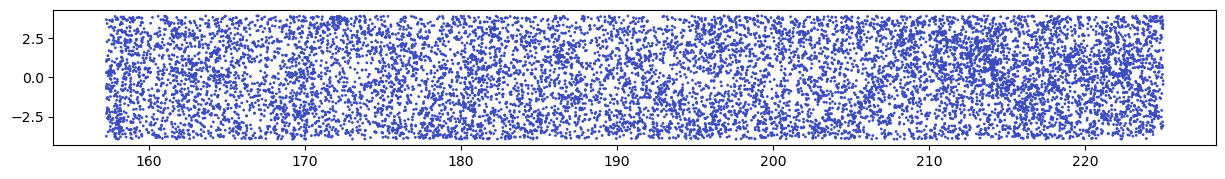

In [102]:
# larger figure
plt.figure(figsize=(15, 2))
plt.scatter(data_conf['ra'], data_conf['dec'], c=data_conf['my_mask'], cmap='coolwarm', s=1)
#equal area
plt.gca().set_aspect('equal', adjustable='box')

In [183]:
# Now check south
REGION = 'wide-S'
gals_south, groups_south = load_and_format_sharks_gals(
    "/Users/sp624AA/Downloads/group_finding_mocks/galaxies_shark.parquet",
    region=REGION
)

/opt/homebrew/anaconda3/envs/nessie_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/sp624AA/Code/groupfinder_masking/src/utils.py:344: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  groups["is_red_bcg"] = groups[group_col].map(bcg_is_red).fillna(False).astype(bool)


In [185]:
my_mask_gals_south = pd.read_parquet('/Users/sp624AA/Code/waves_randoms/waves-wide_s_my_mask_mock.parquet')

In [186]:
# join gals and my mask gals on ra dec, k
combined_gals_s = gals_south.merge(my_mask_gals_south, on=['ra', 'dec'], how='inner')

In [187]:
combined_gals_s['my_mask'] = (combined_gals_s['starmask'] == 0) & (combined_gals_s['polygon_mask'] == 0) & (combined_gals_s['ghostmask'] == 0)

In [188]:
combined_gals_s['my_mask'] = ~combined_gals_s['my_mask']

In [189]:
#combined_gals_s['masked'] = combined_gals_s['my_mask']

In [191]:
# stack the north and south together and save
#final_combined_gals = pd.concat([combined_gals, combined_gals_s], ignore_index=True)
#final_combined_gals.to_parquet("/Users/sp624AA/Downloads/group_finding_mocks/galaxies_filtered_wide_mock_fixed_masking.parquet")

In [47]:
combined_gals_s = combined_gals_s[['ra', 'dec', 'starmask', 'ghostmask', 'polygon_mask', 'my_mask', 'masked']]

In [48]:
conflicts_s = combined_gals_s['my_mask'] != combined_gals_s['masked']

In [50]:
s_confs = combined_gals_s[conflicts_s]

In [62]:
len(combined_gals_s), len(s_confs)

(481205, 16257)

In [57]:
# wrap ra round for plottin
s_confs['ra'] = s_confs['ra'].apply(lambda x: x if x < 180 else x - 360)

/var/folders/87/w15_9chj0tz7_9lhgkpxdbym0000gq/T/ipykernel_17392/868015795.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_confs['ra'] = s_confs['ra'].apply(lambda x: x if x < 180 else x - 360)


In [59]:
s_confs_polygons = s_confs[s_confs['polygon_mask'] == 1]

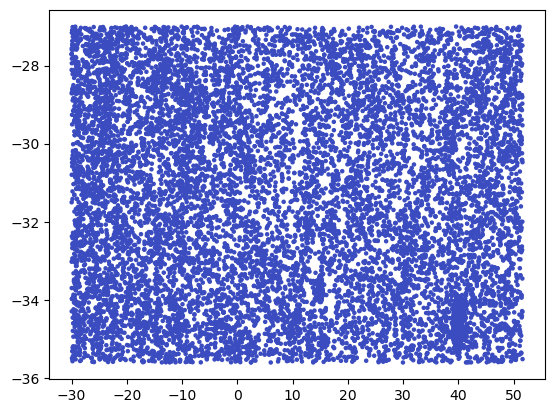

In [58]:

plt.scatter(s_confs['ra'], s_confs['dec'], c=s_confs['my_mask'], cmap='coolwarm', s=5)

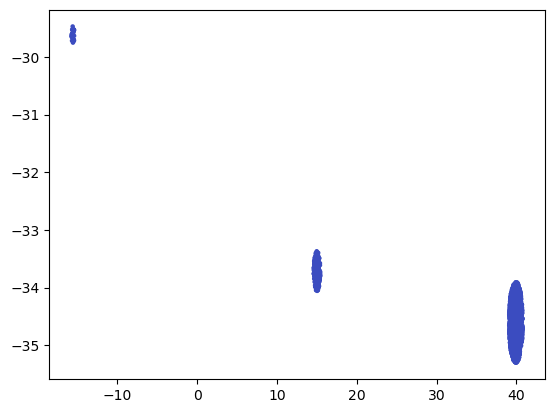

In [60]:

plt.scatter(s_confs_polygons['ra'], s_confs_polygons['dec'], c=s_confs_polygons['my_mask'], cmap='coolwarm', s=5)

In [114]:
star_path = '/Users/sp624AA/Code/waves_polygon_mask/23-06-25_masked_objects_list/Masking/gaiastarmaskwaves.csv'

In [121]:
stars = pd.read_csv(star_path)

def mask_radius_waves(g):
    """
    Calculate r[deg] based on the given formula.

    Parameters:
        g (float or array-like): Input magnitude.

    Returns:
        numpy.ndarray: Calculated r[deg].
    """

    g = np.asarray(g)  # Ensure g is a NumPy array
    r = np.zeros_like(g, dtype=float)
    mask1 = (g > 3.5) & (g < 16)
    mask2 = g <= 3.5
    r[mask1] = (10 ** (1.3 - 0.13 * g[mask1])) 
    r[mask2] = 7 
    return r/60 

# Get masking Radii
stars['radius'] = mask_radius_waves(stars['phot_g_mean_mag'])


In [117]:
stars = stars[(stars['phot_g_mean_mag'] < 16)][['ra', 'dec', 'radius']]

In [122]:
stars

,ra,dec,phot_g_mean_mag,radius
0,53.174832,-33.148467,16.287052,0.000000
1,9.338652,-46.884782,11.439486,0.010832
2,127.805523,-4.458097,13.098638,0.006592
3,128.010233,-4.120998,17.263012,0.000000
4,127.753194,-3.506737,17.367479,0.000000
...,...,...,...,...
2182903,175.411153,3.998017,16.499609,0.000000
2182904,175.499111,3.991698,15.489571,0.003223
2182905,175.486194,3.997755,15.003064,0.003728
2182906,175.362834,3.984571,17.201113,0.000000


In [71]:
ghosts_path = '/Users/sp624AA/Code/waves_polygon_mask/23-06-25_masked_objects_list/Masking/GhostLocations_v0.csv'

In [72]:
ghosts = pd.read_csv(ghosts_path)

In [75]:
ghosts['radius'] = ghosts['radius']/60
ghosts = ghosts[['ra', 'dec', 'radius']]

In [76]:
# vertically stack stars and ghosts
masking_objects = pd.concat([stars, ghosts], ignore_index=True)

(array([6.94657e+05, 8.54520e+04, 2.23900e+04, 8.12000e+03, 3.76200e+03,
        1.89400e+03, 1.07300e+03, 6.03000e+02, 3.87000e+02, 1.05500e+03,
        1.84000e+02, 1.07000e+02, 5.51100e+03, 1.10000e+02, 8.10000e+01,
        5.30000e+01, 5.10000e+01, 2.80000e+01, 2.50000e+01, 1.20000e+01,
        1.40000e+01, 1.60000e+01, 6.00000e+00, 7.00000e+00, 5.00000e+00,
        6.00000e+00, 3.00000e+00, 1.00000e+00, 6.00000e+00, 1.00000e+00]),
 array([0.00276598, 0.00677732, 0.01078867, 0.01480001, 0.01881136,
        0.0228227 , 0.02683405, 0.03084539, 0.03485674, 0.03886808,
        0.04287943, 0.04689077, 0.05090212, 0.05491346, 0.05892481,
        0.06293615, 0.0669475 , 0.07095884, 0.07497018, 0.07898153,
        0.08299287, 0.08700422, 0.09101556, 0.09502691, 0.09903825,
        0.1030496 , 0.10706094, 0.11107229, 0.11508363, 0.11909498,
        0.12310632]),
 <BarContainer object of 30 artists>)

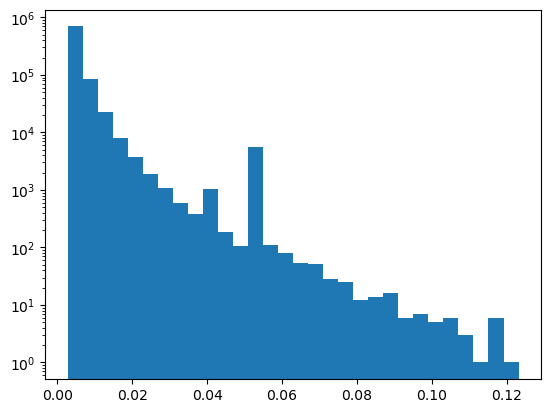

In [81]:
plt.hist(masking_objects['radius'], log=True, bins=30)

In [86]:
areas = np.pi * ghosts['radius']**2

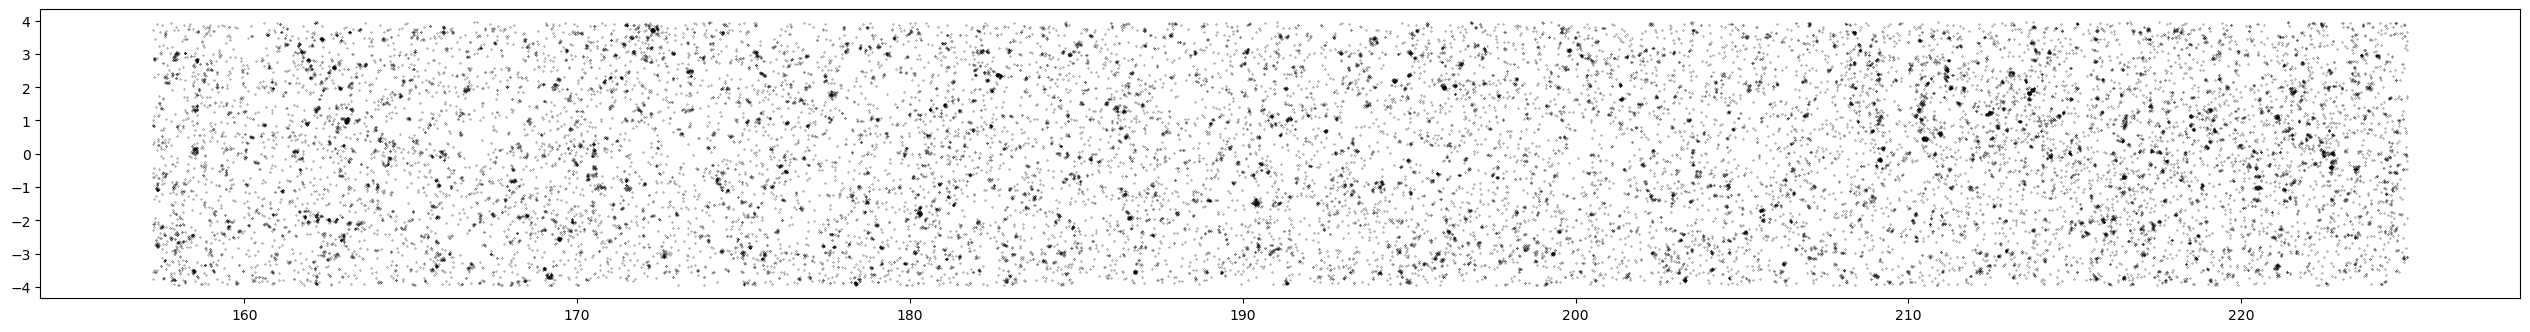

In [162]:
# larger figure
plt.figure(figsize=(32, 4))

gals_m = combined_gals[combined_gals['my_mask'] == True]

plt.scatter(gals_m['ra'], gals_m['dec'], c='black', s=0.05)
#equal area
plt.gca().set_aspect('equal', adjustable='box')

# save fig, high res
plt.savefig('../plots/mask_comparison_my_inv.png', dpi=400)

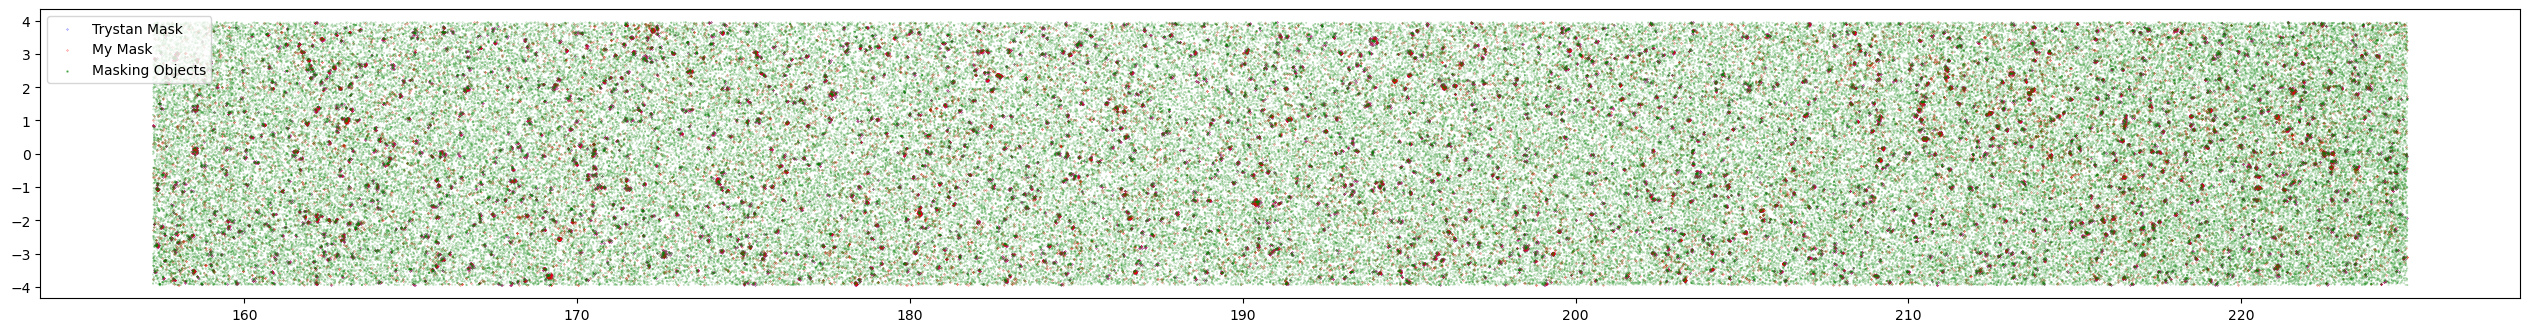

In [169]:
# larger figure
plt.figure(figsize=(32, 4))

gals_m = combined_gals[combined_gals['masked'] == True]

plt.scatter(gals_m['ra'], gals_m['dec'], c='blue', s=0.05, label='Trystan Mask')

gals_mm = combined_gals[combined_gals['my_mask'] == True]

plt.scatter(gals_mm['ra'], gals_mm['dec'], c='red', s=0.05, label='My Mask')

#masking_objs_north = masking_objects[(masking_objects['dec'] > -10)]
ra_360 = masking_objects['ra']#.apply(lambda x: x if x < 180 else x - 360)
mask_wide_N = (
            (ra_360 > 157.25)
            & (ra_360 < 225.0)
            & (masking_objects["dec"] > -3.95)
            & (masking_objects["dec"] < 3.95)
        )
masking_objs_north = masking_objects[mask_wide_N]
#equal area
plt.scatter(masking_objs_north['ra'], masking_objs_north['dec'], c='green', s=masking_objs_north['radius']*10, alpha=0.5, label='Masking Objects')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.savefig('../plots/mask_comparison_inv.png', dpi=400)

/var/folders/87/w15_9chj0tz7_9lhgkpxdbym0000gq/T/ipykernel_17392/177857698.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('../plots/mask_comparison.png', dpi=400)
/opt/homebrew/anaconda3/envs/nessie_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


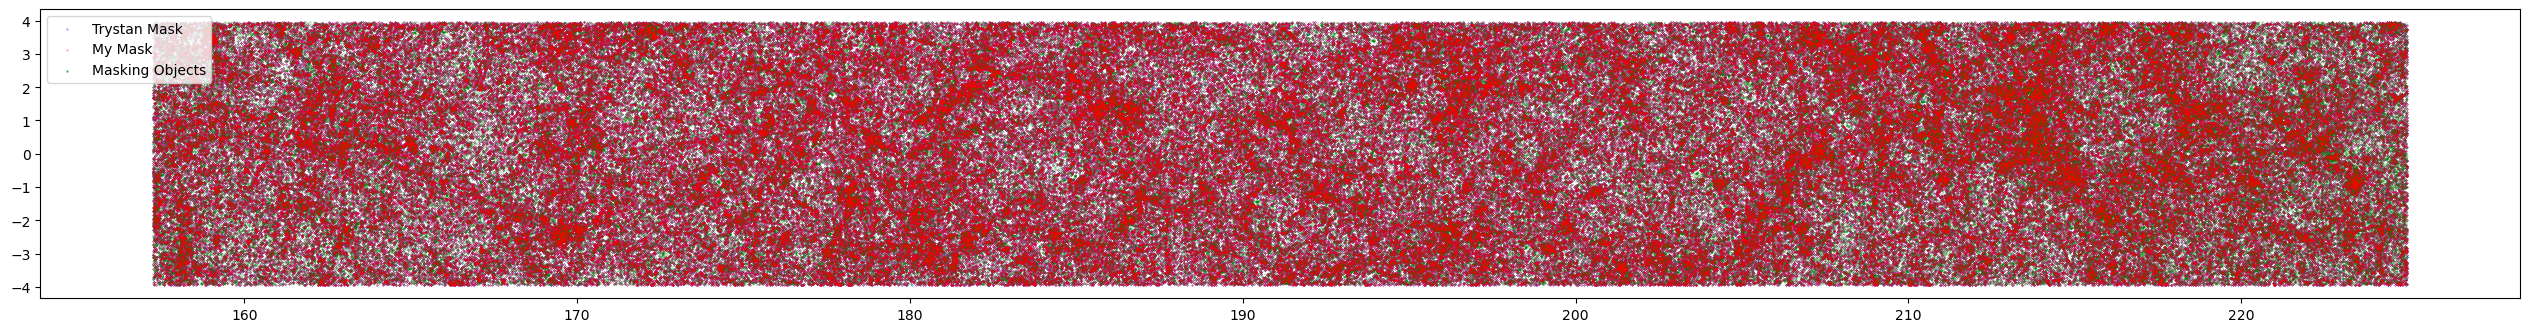

In [170]:
# larger figure
plt.figure(figsize=(32, 4))

gals_m = combined_gals[combined_gals['masked'] == False]

plt.scatter(gals_m['ra'], gals_m['dec'], c='blue', s=0.05, label='Trystan Mask')

gals_mm = combined_gals[combined_gals['my_mask'] == False]

plt.scatter(gals_mm['ra'], gals_mm['dec'], c='red', s=0.05, label='My Mask')

#masking_objs_north = masking_objects[(masking_objects['dec'] > -10)]
ra_360 = masking_objects['ra']#.apply(lambda x: x if x < 180 else x - 360)
mask_wide_N = (
            (ra_360 > 157.25)
            & (ra_360 < 225.0)
            & (masking_objects["dec"] > -3.95)
            & (masking_objects["dec"] < 3.95)
        )
masking_objs_north = masking_objects[mask_wide_N]
#equal area
plt.scatter(masking_objs_north['ra'], masking_objs_north['dec'], c='green', s=masking_objs_north['radius']*10, alpha=0.5, label='Masking Objects')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.savefig('../plots/mask_comparison.png', dpi=400)

In [172]:
import numpy as np

magnitudes = np.array([2.0, 4.0, 10.0, 15.0, 16.0, 17.0])

raddii = np.repeat(7, len(magnitudes))
print(raddii)
print(raddii.dtype)

cut = np.where(magnitudes > 3.5)[0]
raddii[cut] = 10 ** (1.3 - 0.13 * magnitudes[cut])

print(raddii)
print(raddii.dtype)
print(raddii / 60)

[7 7 7 7 7 7]
int64
[7 6 1 0 0 0]
int64
[0.11666667 0.1        0.01666667 0.         0.         0.        ]
